# analysis - cooccurrence by library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
import random
from daforfer import DaforferDB
from scipy import stats
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()
# db.tov()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

In [4]:
cooccurrence_pairs = db.conn.sql('SELECT * FROM D_coocPairDetections').df()
cooccurrence_pairs

,library,pair
0,PV003bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
1,PV004bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
2,PV005bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
3,PV007bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
4,PV012bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
...,...,...
340,PV544,Beet chlorosis virus-Rhodococcoides fascians
341,PV544,Beet western yellows virus-Rhodococcoides fasc...
342,PV544,Agrobacterium tumefaciens-Beet western yellows...
343,PV544,Beet western yellows virus-Sphingomonas sp. Le...


In [5]:
cooccurrence_pairs_counts_by_library = cooccurrence_pairs.value_counts(['library']).reset_index()
cooccurrence_pairs_counts_by_library

,library,count
0,PV215,38
1,PV212,33
2,PV217,19
3,PV218,17
4,PV224,16
...,...,...
70,PV132,1
71,PV157,1
72,PV169,1
73,PV004bgi,1


In [6]:
all_libraries = db.conn.sql("SELECT * FROM D_sites").df()[['library', 'site', 'habitat', 'host_taxon']].drop_duplicates("library")

cooccurrence_pairs_counts_by_library = pd.merge(all_libraries, cooccurrence_pairs_counts_by_library, on='library', how='left').fillna(0).sort_values(by='count', ascending=False)
cooccurrence_pairs_counts_by_library['pos'] = np.arange(len(cooccurrence_pairs_counts_by_library))
cooccurrence_pairs_counts_by_library

,library,site,habitat,host_taxon,count,pos
189,PV215,L3,Edge,Conyza bonariensis,38.0,0
186,PV212,L3,Edge,Amaranthus sp,33.0,1
191,PV217,L3,Edge,Datura stramonium,19.0,2
192,PV218,L3,Edge,Daucus sp,17.0,3
197,PV224,L3,Edge,Vicia sp,16.0,4
...,...,...,...,...,...,...
158,PV193,L2,Edge,Galium verum,0.0,318
159,PV194,L2,Edge,Papaver rhoeas,0.0,319
160,PV195,L2,Edge,Picris echioides,0.0,320
1,PV535,C1,Crop,Brassica oleracea,0.0,321


In [7]:
cooccurrence_pairs_counts_by_library[['count']].describe().round(4)

,count
count,323.0000
mean,1.0681
std,3.7110
min,0.0000
25%,0.0000
50%,0.0000
75%,0.0000
max,38.0000


In [8]:
cooccurrence_pairs_counts_by_library.query('count > 0')[['count']].describe().round(4)

,count
count,75.0000
mean,4.6000
std,6.5924
min,1.0000
25%,1.0000
50%,2.0000
75%,5.0000
max,38.0000


In [9]:
cooccurrence_pairs_counts_by_library = cooccurrence_pairs_counts_by_library[['library', 'site', 'habitat', 'host_taxon', 'count']]
cooccurrence_pairs_counts_by_library['count'] = cooccurrence_pairs_counts_by_library['count'].astype(int)
cooccurrence_pairs_counts_by_library

/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_19598/4000376895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cooccurrence_pairs_counts_by_library['count'] = cooccurrence_pairs_counts_by_library['count'].astype(int)


,library,site,habitat,host_taxon,count
189,PV215,L3,Edge,Conyza bonariensis,38
186,PV212,L3,Edge,Amaranthus sp,33
191,PV217,L3,Edge,Datura stramonium,19
192,PV218,L3,Edge,Daucus sp,17
197,PV224,L3,Edge,Vicia sp,16
...,...,...,...,...,...
158,PV193,L2,Edge,Galium verum,0
159,PV194,L2,Edge,Papaver rhoeas,0
160,PV195,L2,Edge,Picris echioides,0
1,PV535,C1,Crop,Brassica oleracea,0


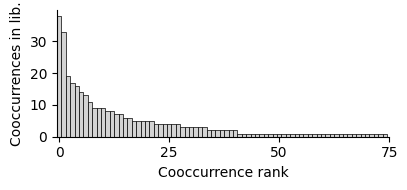

In [10]:
g = sns.catplot(
    x='library', y='count', 
    data=cooccurrence_pairs_counts_by_library.query('count > 0'), 
    kind='bar', dodge=False, height=2.0, aspect=2.0, edgecolor='black', linewidth=0.5, width=1.0,
    color='lightgray'
)
g.ax.set_xticks([0, 25, 50, 75])
g.set_xticklabels([0, 25, 50, 75])
g.set_xlabels("Cooccurrence rank")
g.set_ylabels("Cooccurrences in lib.")
g.savefig("figures/barplot.cooccurrences_by_library.svg")

## Cooccurrences by host

In [11]:
all_libraries

,library,site,habitat,host_taxon
0,PV534,C1,Crop,Diplotaxis erucoides
1,PV535,C1,Crop,Brassica oleracea
2,PV538,C1,Crop,Brassica oleracea
3,PV540,C1,Crop,Picris echioides
4,PV544,C1,Crop,Sisymbrium runcinatum
...,...,...,...,...
330,PV590,Z1,Crop,Zea mays
331,PV047,Z2,Crop,Zea mays
332,PV048,Z2,Crop,Desconocida 4
333,PV527,Z2,Crop,Convolvulus arvensis


In [12]:
host_habitat = all_libraries.groupby(['host_taxon'])['habitat'].apply(lambda x: ", ".join(list(set(x))))
host_habitat

host_taxon
Allium sativum                           Edge
Amaranthus sp                      Edge, Crop
Anacyclus clavatus      Wasteland, Crop, Edge
Anchusa undulata              Wasteland, Edge
Andryala arenaria                         Oak
                                ...          
Trifolium tomentosum                Wasteland
Verbascum sinuatum                  Wasteland
Vicia sp                      Wasteland, Edge
Xanthium strumarium                      Crop
Zea mays                                 Crop
Name: habitat, Length: 119, dtype: object

In [13]:
cooccurrence_by_host = pd.merge(cooccurrence_pairs, all_libraries, on='library').drop_duplicates(['host_taxon', 'pair'])[['host_taxon', 'pair']].value_counts('host_taxon').reset_index()
cooccurrence_by_host

,host_taxon,count
0,Conyza bonariensis,38
1,Amaranthus sp,36
2,Diplotaxis erucoides,21
3,Datura stramonium,20
4,Carduus bourgeanus,19
5,Daucus sp,19
6,Convolvulus arvensis,19
7,Vicia sp,17
8,Rubia peregrina,12
9,Cynodon dactylon,9


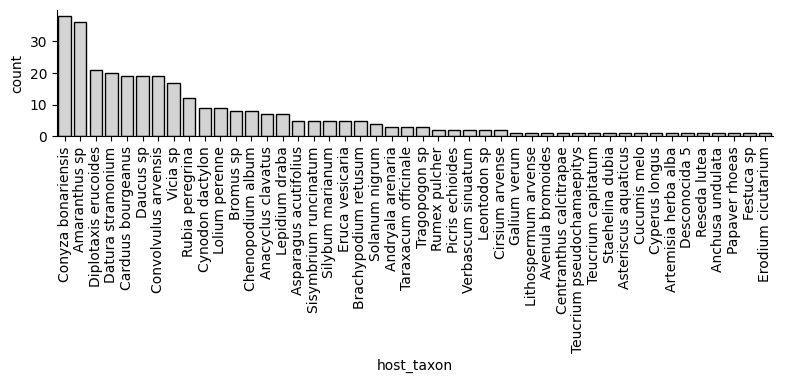

In [16]:
g = sns.catplot(cooccurrence_by_host, x='host_taxon', y='count', height=2.0, aspect=4.0, kind='bar', color='lightgray', edgecolor='black')
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.host_taxon_cooccurrences.svg")

In [17]:
cooccurrence_by_host = pd.merge(host_habitat, cooccurrence_by_host, on='host_taxon', how='left').fillna(0).sort_values(by='count', ascending=False)
cooccurrence_by_host['count'] = cooccurrence_by_host['count'].astype(int)
cooccurrence_by_host

,host_taxon,habitat,count
29,Conyza bonariensis,Edge,38
1,Amaranthus sp,"Edge, Crop",36
41,Diplotaxis erucoides,"Wasteland, Crop, Edge",21
36,Datura stramonium,"Edge, Crop",20
37,Daucus sp,Edge,19
...,...,...,...
53,Geranium sp,"Wasteland, Oak, Edge",0
51,Fumaria parviflora,"Edge, Crop",0
50,Foeniculum vulgare,Wasteland,0
48,Eryngium campestre,"Wasteland, Oak",0


In [18]:
cooccurrence_by_host

,host_taxon,habitat,count
29,Conyza bonariensis,Edge,38
1,Amaranthus sp,"Edge, Crop",36
41,Diplotaxis erucoides,"Wasteland, Crop, Edge",21
36,Datura stramonium,"Edge, Crop",20
37,Daucus sp,Edge,19
...,...,...,...
53,Geranium sp,"Wasteland, Oak, Edge",0
51,Fumaria parviflora,"Edge, Crop",0
50,Foeniculum vulgare,Wasteland,0
48,Eryngium campestre,"Wasteland, Oak",0


In [19]:
cooccurrence_by_host_habitat = pd.merge(cooccurrence_pairs, all_libraries, on='library').drop_duplicates(['host_taxon', 'habitat', 'pair'])[['host_taxon', 'habitat', 'pair']].value_counts(['host_taxon', 'habitat']).reset_index().pivot(index='host_taxon', columns='habitat', values='count').fillna(0)
cooccurrence_by_host = pd.merge(cooccurrence_by_host, cooccurrence_by_host_habitat, on='host_taxon', how='left').fillna(0)
cooccurrence_by_host['Crop'] = cooccurrence_by_host['Crop'].astype(int)
cooccurrence_by_host['Edge'] = cooccurrence_by_host['Edge'].astype(int)
cooccurrence_by_host['Oak'] = cooccurrence_by_host['Oak'].astype(int)
cooccurrence_by_host['Wasteland'] = cooccurrence_by_host['Wasteland'].astype(int)
cooccurrence_by_host

,host_taxon,habitat,count,Crop,Edge,Oak,Wasteland
0,Conyza bonariensis,Edge,38,0,38,0,0
1,Amaranthus sp,"Edge, Crop",36,0,36,0,0
2,Diplotaxis erucoides,"Wasteland, Crop, Edge",21,8,15,0,0
3,Datura stramonium,"Edge, Crop",20,1,19,0,0
4,Daucus sp,Edge,19,0,19,0,0
...,...,...,...,...,...,...,...
114,Geranium sp,"Wasteland, Oak, Edge",0,0,0,0,0
115,Fumaria parviflora,"Edge, Crop",0,0,0,0,0
116,Foeniculum vulgare,Wasteland,0,0,0,0,0
117,Eryngium campestre,"Wasteland, Oak",0,0,0,0,0


In [20]:
cooccurrence_by_host = pd.merge(
    cooccurrence_by_host, 
    all_libraries.value_counts('host_taxon').reset_index().rename(columns={'count': 'n_libraries'}),
    how='left', on='host_taxon'
)
cooccurrence_by_host

,host_taxon,habitat,count,Crop,Edge,Oak,Wasteland,n_libraries
0,Conyza bonariensis,Edge,38,0,38,0,0,2
1,Amaranthus sp,"Edge, Crop",36,0,36,0,0,5
2,Diplotaxis erucoides,"Wasteland, Crop, Edge",21,8,15,0,0,11
3,Datura stramonium,"Edge, Crop",20,1,19,0,0,3
4,Daucus sp,Edge,19,0,19,0,0,3
...,...,...,...,...,...,...,...,...
114,Geranium sp,"Wasteland, Oak, Edge",0,0,0,0,0,4
115,Fumaria parviflora,"Edge, Crop",0,0,0,0,0,4
116,Foeniculum vulgare,Wasteland,0,0,0,0,0,2
117,Eryngium campestre,"Wasteland, Oak",0,0,0,0,0,2


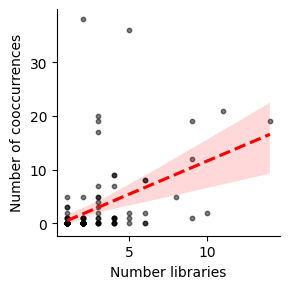

In [25]:
g = sns.lmplot(cooccurrence_by_host, x='n_libraries', y='count',
        height=3.0, 
        scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, 
        line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Number libraries")
g.set_ylabels("Number of cooccurrences")
g.savefig("figures/lmplot.libraries-cooccurrences.svg")

In [22]:
stats.linregress(cooccurrence_by_host['n_libraries'], cooccurrence_by_host['count'])

LinregressResult(slope=np.float64(1.2362437471577992), intercept=np.float64(-0.716863280100581), rvalue=np.float64(0.44442578124172893), pvalue=np.float64(4.120506584860742e-07), stderr=np.float64(0.2303724762002708), intercept_stderr=np.float64(0.8192668072550685))

In [ ]:
cooccurrence_by_host.query('count > 0').describe()

,count,Crop,Edge,Oak,Wasteland,n_libraries
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000
mean,6.826087,0.695652,5.391304,0.239130,0.717391,4.043478
std,8.877698,1.697967,9.017214,0.565087,1.515300,2.988545
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,3.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,8.000000,0.750000,7.000000,0.000000,1.000000,5.000000
max,38.000000,8.000000,38.000000,3.000000,8.000000,14.000000


: 

## Cooccurrence against hits

In [19]:
bacteria_hits = db.conn.sql("SELECT * FROM D_PABHits").df()
virus_hits = db.conn.sql("SELECT * FROM D_VirusHits").df()
bacteria_hits['kingdom'] = 'bacteria'
virus_hits['kingdom'] = 'virus'
virus_hits

,library,acronym,taxid,scientific_name,kingdom
0,PV001,CMV3,12305,Cucumber mosaic virus RNA 3,virus
1,PV001,CmEV,1776177,Cucumis melo endornavirus,virus
2,PV001,GMMV3,578305,Gayfeather mild mottle virus RNA 3,virus
3,PV001,RuCMV,378833,Rubus chlorotic mottle virus,virus
4,PV002,CMV3,12305,Cucumber mosaic virus RNA 3,virus
...,...,...,...,...,...
1611,PV589,CYDV_RPV,2170100,Cereal yellow dwarf virus - RPV,virus
1612,PV589,WYDV_GPV,572239,Wheat yellow dwarf virus - GPV,virus
1613,PV590,CMV_satRNA,None,Cucumber mosaic virus satellite RNA,virus
1614,PV590,RuCMV,378833,Rubus chlorotic mottle virus,virus


In [20]:
coocurrence_results = pd.read_csv(
    "output/coocurrence.virusbact-bylibrary.csv", sep=',', index_col=0
)
bacteria_names = bacteria_hits['scientific_name'].to_list()
virus_names = virus_hits['scientific_name'].to_list()
name_kingdom_map = {}
for b in bacteria_names:
    name_kingdom_map[b] = 'Bacteria'
for v in virus_names:
    name_kingdom_map[v] = 'Virus'
coocurrence_results['sp1_kingdom'] = coocurrence_results['sp1_name'].map(name_kingdom_map)
coocurrence_results['sp2_kingdom'] = coocurrence_results['sp2_name'].map(name_kingdom_map)
coocurrence_results = coocurrence_results.dropna(subset=['sp1_name', 'sp2_name'])
coocurrence_results = coocurrence_results.query('p_gt < 0.05 or p_lt < 0.05')
table_sx = coocurrence_results[coocurrence_results.apply(lambda x: x.sp1_kingdom != x.sp2_kingdom, axis=1)][['sp1_name', 'sp2_name', 'p_lt', 'p_gt', 'obs_cooccur', 'exp_cooccur']]
table_sx['positive'] = table_sx.apply(lambda x: 'positive' if x.p_gt < 0.05 else 'neutral', axis=1)
table_sx['negative'] = table_sx.apply(lambda x: 'negative' if x.p_lt < 0.05 else 'neutral', axis=1)
table_sx['type'] = np.select(
    [table_sx['positive'] == 'positive', table_sx['negative'] == 'negative'],
    ['positive', 'negative'],
    default='non-significative'
)
table_sx = table_sx.query('type != "non-significative"')[['sp1_name', 'sp2_name', 'p_lt', 'p_gt', 'obs_cooccur', 'exp_cooccur', 'type']]
table_sx

,sp1_name,sp2_name,p_lt,p_gt,obs_cooccur,exp_cooccur,type
145,Beet chlorosis virus,Duffyella gerundensis,0.99340,0.03617,4,1.4,positive
146,Beet chlorosis virus,Frigoribacterium sp. Leaf164,0.99920,0.00448,7,2.3,positive
149,Beet chlorosis virus,Pseudomonas oryzihabitans,0.99980,0.00211,5,1.1,positive
150,Beet chlorosis virus,Rhodococcoides fascians,0.99349,0.03026,5,1.9,positive
185,Beet mild yellowing virus,Frigoribacterium sp. Leaf164,0.99920,0.00448,7,2.3,positive
188,Beet mild yellowing virus,Pseudomonas oryzihabitans,0.99980,0.00211,5,1.1,positive
220,Beet western yellows virus,Agrobacterium tumefaciens,0.99506,0.03201,4,1.4,positive
221,Beet western yellows virus,Arthrobacter sp. Leaf234,0.99782,0.01427,5,1.7,positive
229,Beet western yellows virus,Pseudomonas oryzihabitans,0.99950,0.00386,6,1.8,positive
230,Beet western yellows virus,Pseudomonas sp. Leaf127,0.99506,0.03201,4,1.4,positive


In [21]:
M = nx.Graph()
M.add_edges_from(table_sx[['sp1_name', 'sp2_name']].values.tolist())
org_degree = pd.DataFrame(list(M.degree()), columns=['scientific_name', 'degree'])
org_degree

,scientific_name,degree
0,Beet chlorosis virus,4
1,Duffyella gerundensis,4
2,Frigoribacterium sp. Leaf164,5
3,Pseudomonas oryzihabitans,8
4,Rhodococcoides fascians,7
5,Beet mild yellowing virus,2
6,Beet western yellows virus,6
7,Agrobacterium tumefaciens,3
8,Arthrobacter sp. Leaf234,9
9,Pseudomonas sp. Leaf127,1


In [22]:
bacteria_hits.value_counts(['scientific_name', 'kingdom']).reset_index()

,scientific_name,kingdom,count
0,Frigoribacterium sp. Leaf164,bacteria,26
1,Rhodococcoides fascians,bacteria,21
2,Pseudomonas lutea,bacteria,21
3,Methylobacterium sp. Leaf125,bacteria,16
4,Chryseobacterium sp. Leaf201,bacteria,16
...,...,...,...
122,Pseudomonas sp. Leaf48,bacteria,1
123,Cupriavidus basilensis,bacteria,1
124,Pseudomonas vancouverensis,bacteria,1
125,Pseudorhodoferax sp. Leaf265,bacteria,1


In [23]:
org_degree = pd.merge(
    pd.concat([bacteria_hits.value_counts(['scientific_name', 'kingdom']).reset_index(), virus_hits.value_counts(['scientific_name', 'kingdom']).reset_index()]),
    org_degree, on='scientific_name', how='left'
).fillna(0).rename(columns={'count': 'hits', 'degree': 'cooccurrences'})
org_degree

,scientific_name,kingdom,hits,cooccurrences
0,Frigoribacterium sp. Leaf164,bacteria,26,5.0
1,Rhodococcoides fascians,bacteria,21,7.0
2,Pseudomonas lutea,bacteria,21,1.0
3,Methylobacterium sp. Leaf125,bacteria,16,2.0
4,Chryseobacterium sp. Leaf201,bacteria,16,0.0
...,...,...,...,...
280,Datura yellow vein virus,virus,1,0.0
281,Lettuce mosaic virus,virus,1,0.0
282,Spinach severe curly top virus,virus,1,0.0
283,Cymbidium ringspot virus,virus,1,0.0


In [24]:
org_degree

,scientific_name,kingdom,hits,cooccurrences
0,Frigoribacterium sp. Leaf164,bacteria,26,5.0
1,Rhodococcoides fascians,bacteria,21,7.0
2,Pseudomonas lutea,bacteria,21,1.0
3,Methylobacterium sp. Leaf125,bacteria,16,2.0
4,Chryseobacterium sp. Leaf201,bacteria,16,0.0
...,...,...,...,...
280,Datura yellow vein virus,virus,1,0.0
281,Lettuce mosaic virus,virus,1,0.0
282,Spinach severe curly top virus,virus,1,0.0
283,Cymbidium ringspot virus,virus,1,0.0


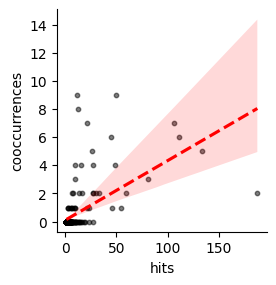

In [25]:
sns.lmplot(org_degree, x='hits', y='cooccurrences', height=3.0, scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'})

In [26]:
print(stats.linregress(org_degree['hits'], org_degree['cooccurrences']).pvalue)

6.389169942672128e-26


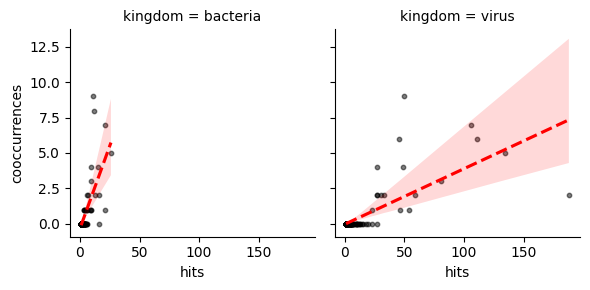

In [27]:
sns.lmplot(org_degree, col='kingdom', x='hits', y='cooccurrences', height=3.0, scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'})

In [28]:
stats.linregress(
    org_degree.query('kingdom == "bacteria"')['hits'], 
    org_degree.query('kingdom == "bacteria"')['cooccurrences']
)

LinregressResult(slope=np.float64(0.23343390471138226), intercept=np.float64(-0.33315208381684963), rvalue=np.float64(0.7060582016743299), pvalue=np.float64(1.8465021452968862e-20), stderr=np.float64(0.020940932688043663), intercept_stderr=np.float64(0.11541845911259893))

In [29]:
stats.linregress(
    org_degree.query('kingdom == "virus"')['hits'], 
    org_degree.query('kingdom == "virus"')['cooccurrences']
)

LinregressResult(slope=np.float64(0.039191902118841736), intercept=np.float64(-0.02743110015220407), rvalue=np.float64(0.7181974379230359), pvalue=np.float64(2.3839588972728734e-26), stderr=np.float64(0.0030401792696530734), intercept_stderr=np.float64(0.0795558716557125))

In [30]:
db.close()